### Simple Linear Regression

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm

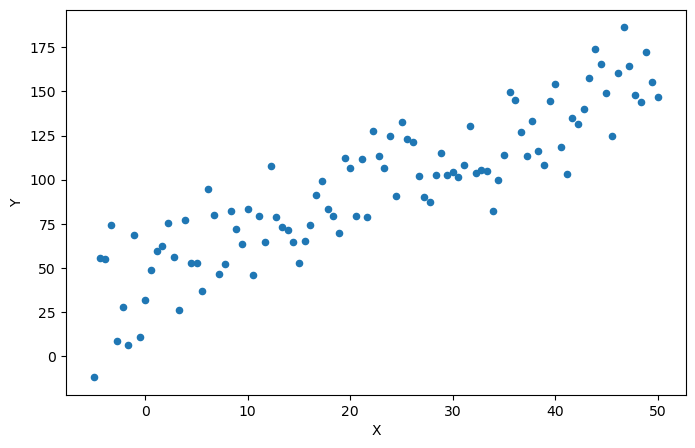

In [6]:
# Generate the data
x = np.linspace(-5, 50, 100)
y = 50 + 2 * x + np.random.normal(0, 20, size=len(x))
data = pd.DataFrame({'X': x, 'Y': y})

data.plot.scatter(x='X', y='Y', figsize=(8,5))
plt.show()

Consider a simple linear model with a single independent variable:

$$y = \beta_0 + \beta_1 X_1 + \epsilon$$

$\epsilon$ is the error term, accounts for deviation from the linear model

By minimizing the residual sum of squares we obtain

$$\hat{\beta} = (X^T X)^{-1} (X^T y)$$

we can quickly derive the vector $\hat{\beta}$ by inverting the matrix $X^T X$

In [14]:
X = sm.add_constant(data.X)
beta = np.linalg.inv(X.T @ X) @ (X.T @ y)
beta

array([45.52578789,  2.24627036])

In [16]:
X = sm.add_constant(data.X)
model = sm.OLS(data.Y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.786
Model:                            OLS   Adj. R-squared:                  0.784
Method:                 Least Squares   F-statistic:                     360.2
Date:                Mon, 15 Jun 2026   Prob (F-statistic):           1.37e-34
Time:                        15:53:24   Log-Likelihood:                -435.23
No. Observations:                 100   AIC:                             874.5
Df Residuals:                      98   BIC:                             879.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         45.5258      3.270     13.921      0.0

Note that t-statistics for both parameters are > 10 and the associated p-values are very low, this tells us that both parameters are statistically significant

#### Analysis of Residuals

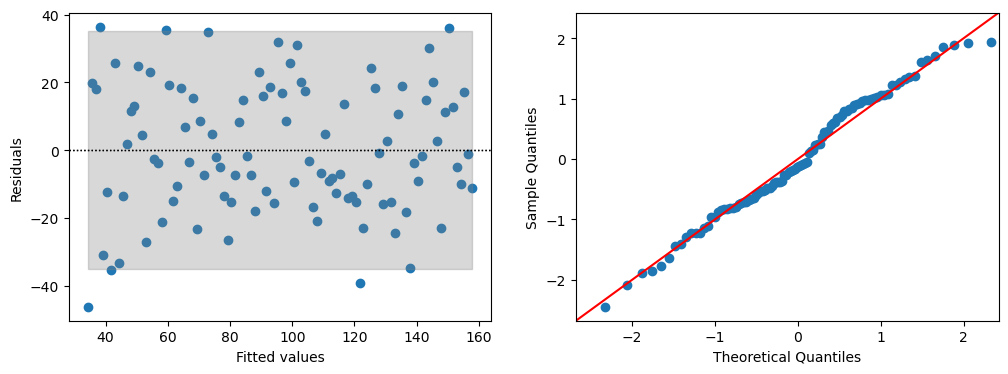

In [35]:
intercept = model.params['const']
slope = model.params['X']
residuals = model.resid.to_numpy()
y_hat = intercept + x * slope

residuals_ci = np.quantile(residuals, [0.025, 0.975])

fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].scatter(y_hat, residuals)
ax[0].axhline(0, lw=1, ls=':', color='black')
ax[0].fill_between(y_hat, residuals_ci[0], residuals_ci[1], alpha=0.3, color='grey')
ax[0].axhline(0, lw=1, ls=':', color='black')
ax[0].set_xlabel('Fitted values')
ax[0].set_ylabel('Residuals')

sm.qqplot(residuals, ax=ax[1], fit=True, line='45')

plt.show()

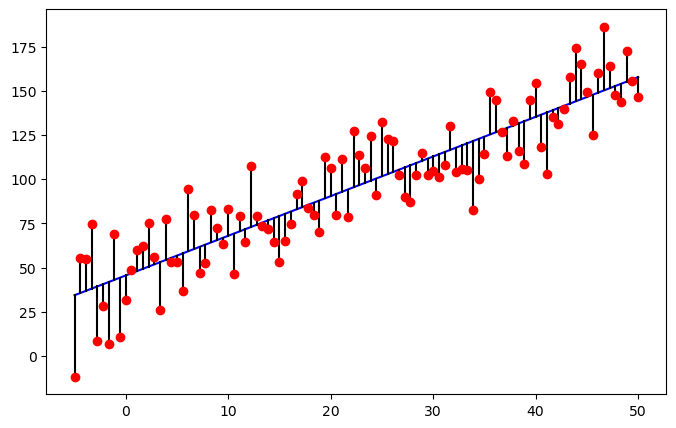

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8,5))
ax.plot(data.X, y_hat, color='blue')
for i in range(len(data.X)):
    ax.plot((data.X[i], data.X[i]), (y_hat[i], data.Y[i]), 'k-')

ax.scatter(data.X, data.Y, color='red', zorder=4)
ax.set_xlabel()
ax.set_ylabel()
plt.show()

### Multiple Linear Regression

Consider now two independent variables, the model simply changes as follows:

$$y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \epsilon$$

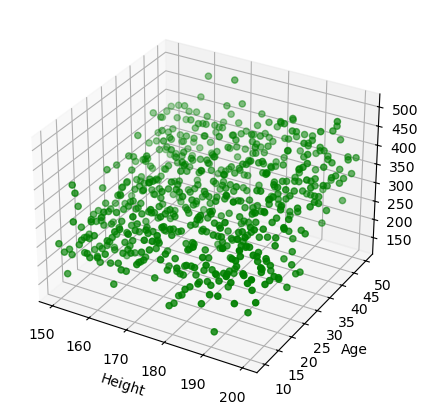

In [ ]:
# Generate data
size = 25
X_1, X_2 = np.meshgrid(np.linspace(150, 200, size), np.linspace(10, 50, size), indexing='ij')
data = pd.DataFrame({'Height': X_1.ravel(), 'Age': X_2.ravel()})
data['Y'] = 50 + data.Height + 3 * data.Age + np.random.normal(0, 50, size=size**2)

fig = plt.figure(figsize=(5, 8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(data["Height"], data["Age"], data["Y"], c='g')
ax.set_xlabel("Height")
ax.set_ylabel("Age")
ax.set_zlabel("Y")
plt.show()

In [52]:
# Using the inverse of X.T X
X = data[['Height', 'Age']]
X = sm.add_constant(X)
y = data.Y.to_numpy()
beta = np.linalg.inv(X.T @ X) @ (X.T @ y)
beta

array([81.51940306,  0.81270486,  2.99489438])

In [ ]:
X = data[['Height', 'Age']]
X = sm.add_constant(X)


model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.362
Model:                            OLS   Adj. R-squared:                  0.360
Method:                 Least Squares   F-statistic:                     176.5
Date:                Mon, 15 Jun 2026   Prob (F-statistic):           1.90e-61
Time:                        16:52:07   Log-Likelihood:                -3337.4
No. Observations:                 625   AIC:                             6681.
Df Residuals:                     622   BIC:                             6694.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         81.5194     24.182      3.371      0.0

#### Analysis of Residuals

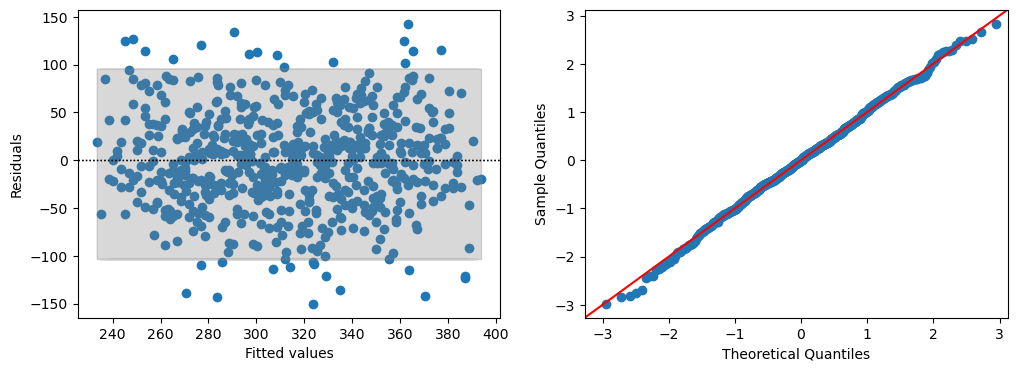

In [53]:
intercept = model.params['const']
residuals = model.resid.to_numpy()
residuals_ci = np.quantile(residuals, [0.025, 0.975])
y_hat = model.predict(X)

fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].scatter(y_hat, residuals)
ax[0].axhline(0, lw=1, ls=':', color='black')
ax[0].fill_between(y_hat, residuals_ci[0], residuals_ci[1], alpha=0.3, color='grey')
ax[0].axhline(0, lw=1, ls=':', color='black')
ax[0].set_xlabel('Fitted values')
ax[0].set_ylabel('Residuals')

sm.qqplot(residuals, ax=ax[1], fit=True, line='45')

plt.show()